In [10]:
import h5py
import numpy as np    
import matplotlib.pyplot as plt
import os
import argparse
import tqdm
import matplotlib
from matplotlib.animation import FuncAnimation, PillowWriter
import scipy.ndimage.filters as filters
plt.rcParams.update({
    # "text.usetex": True,
    "font.family": 'STIXGeneral',
    "text.latex.preamble": r"\usepackage{lmodern}",
    'mathtext.fontset': 'cm'
})
fs = 15
fstick = 12


def smooth( x, window_len=61, window='hanning', axis = -1):
    return filters.convolve1d(x, np.ones(window_len)/window_len, axis=axis)

datafolder = "/travail/xgong/test_mpi/output/mi25-MA40_jpt2"
# datafolder = "/travail/xgong/test_separate/output/mi25-MA40_large"
import re

match = re.search(r'mi(\d+)', datafolder)
if match:
    mi = float(match.group(1))
    print(mi)
else:
    print("no mi")

os.system('ls '+ os.path.join(datafolder, 'particles/partic*h5') + ' > ' + os.path.join(datafolder, 'filelist_prtl.txt'))
with open(os.path.join(datafolder, 'filelist_prtl.txt')) as f:
    files = f.readlines()
    for i in range(len(files)):
        files[i] = files[i].strip()
print(len(files))


os.system('ls '+ os.path.join(datafolder, 'fields/*h5') + ' > ' + os.path.join(datafolder, 'filelist_flds.txt'))
with open(os.path.j_largeoin(datafolder, 'filelist_flds.txt')) as f:
    files_fld = f.readlines()
    for i in range(len(files_fld)):
        files_fld[i] = files_fld[i].strip()
# print(len(files))
%matplotlib widget

25.0
20


AttributeError: module 'posixpath' has no attribute 'j_largeoin'

<KeysViewHDF5 ['Step', 'Time', 'pIDX_1', 'pIDX_2', 'pPLDI0_1', 'pPLDI0_2', 'pPLDI1_1', 'pPLDI1_2', 'pPLDR0_1', 'pPLDR0_2', 'pRNK_1', 'pRNK_2', 'pU1_1', 'pU1_2', 'pU2_1', 'pU2_2', 'pU3_1', 'pU3_2', 'pW_1', 'pW_2', 'pX1_1', 'pX1_2']>


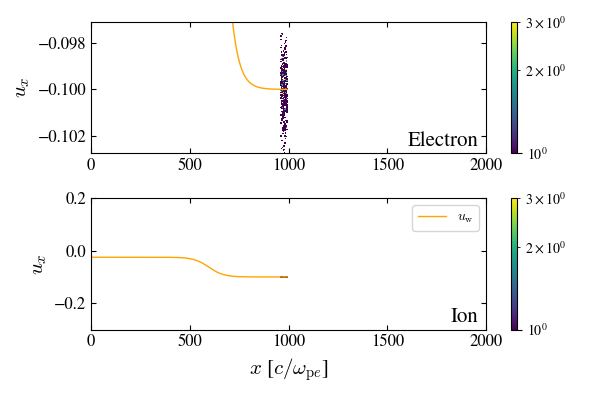

In [ ]:
x = -1
import matplotlib

def getuw(x,Xsh, Lsh, driftux):
    return (5./8. + 3./8. * np.tanh(2 * (x - Xsh)/Lsh)) * ( - driftux)
file = h5py.File(files[x], 'r')['Step0']
file_fld =h5py.File( files_fld[x], 'r')['Step0']
B3 = (np.array(file_fld['fAvgBz']))
E2 = (np.array(file_fld['fAvgEy']))
X_fld = np.array(file_fld['X1'])
vEB = (E2 / B3)


print(file.keys())
u11 = np.array(file['pU1_1'])
u12 = np.array(file['pU1_2'])
u21 = np.array(file['pU2_1'])
u22 = np.array(file['pU2_2'])
u31 = np.array(file['pU3_1'])
u32 = np.array(file['pU3_2'])
x1 = np.array(file['pX1_1'])
x2 = np.array(file['pX1_2'])

# xmax = x2.max()
xmin,xmax = 0,x1.max()
fill=0.6
numx, numu = 400,300

fig,(ax1, ax2) = plt.subplots(2,figsize = (6,4))
res = ax1.hist2d(x1, u11, bins=(np.linspace(xmin,xmax,numx),np.linspace(u11.min(),u11.max(),numu)), norm=matplotlib.colors.LogNorm())
ax1.set_ylabel(r'$u_x$', fontsize= 15)
# ax1.set_xlabel(r'$x$ [$c / \omega_{\mathrm{p}e}$]', fontsize= 15)
# ax1.plot([0,xmax],[-0.1,-0.1], color = 'red', lw=0.5)
fig.colorbar(ax = ax1, mappable=res[3])
# uprob = (res[2][1:] * res[0]).sum(1)/ res[0].sum(1)
uprob = (res[2][np.argmax(res[0],1)])
# plt.plot(np.linspace(xmin,xmax,numx)[1:], uprob, color = 'black')
ax1.plot(np.linspace(xmin,xmax,numx), getuw(np.linspace(xmin,xmax,numx),x1.max()*fill, 150, 0.1), color = 'orange', lw = 1,label = r'$u_\mathrm{w}$')
# ax1.plot(X_fld, vEB, color='red', label='Ex_large
ax1.text(
    0.98, 0.02,            
    "Electron",               
    transform=ax1.transAxes,
    ha='right', va='bottom',
    fontsize=  15
)

# plt.ylim(-3,3e3)


res = ax2.hist2d(x2, u12, bins=(np.linspace(xmin,xmax,numx),np.linspace(u12.min(),u12.max(),numu)), norm=matplotlib.colors.LogNorm())

ax2.set_ylabel(r'$u_x$', fontsize= 15)
ax2.set_xlabel(r'$x$ [$c / \omega_{\mathrm{p}e}$]', fontsize= 15)
# ax2.plot([xmin,xmax],[-0.1,-0.1], color = 'red', lw=0.5)
# ax2.plot(X_fld, vEB, color='red', label='ExB',lw = 1)
ax2.plot(np.linspace(xmin,xmax,numx), getuw(np.linspace(xmin,xmax,numx),x1.max()*fill, 150, 0.1), color = 'orange',lw = 1, label = r'$u_\mathrm{w}$')
ax2.text(
    0.98, 0.02,              
    "Ion",               
    transform=ax2.transAxes,
    ha='right', va='bottom',
    fontsize=  15
)

fig.colorbar(ax = ax2, mappable=res[3])
ax2.legend()
ax1.set_xlim(0,2e3)
ax2.set_xlim(0,2e3)
ax2.set_ylim(-0.3,0.2)

plt.tight_layout()
ax1.tick_params(which='minor', direction='in', length=3, width=0.5, colors='k', grid_color='r', grid_alpha=0.5, labelsize=fstick)
ax1.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=fstick)
ax2.tick_params(which='minor', direction='in', length=3, width=0.5, colors='k', grid_color='r', grid_alpha=0.5, labelsize=fstick)
ax2.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=fstick)
# plt.savefig("./plots/IonPhaseMA400.png", dpi = 500, bbox_size = 'tight')
# plt.savefig("./plots/MA40Prtl.png", dpi = 500, bbox_size = 'tight')


/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:27: RuntimeWarning: Mean of empty slice.
/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/numpy/core/_methods.py:170: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:28: RuntimeWarning: Mean of empty slice.
/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:29: RuntimeWarning: Mean of empty slice.
/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:72: RuntimeWarning: invalid value encountered in double_scalars
/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:27: RuntimeWarning: Mean of empty slice.
/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/numpy/core/_methods.py:170: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/mesopsl3/hom

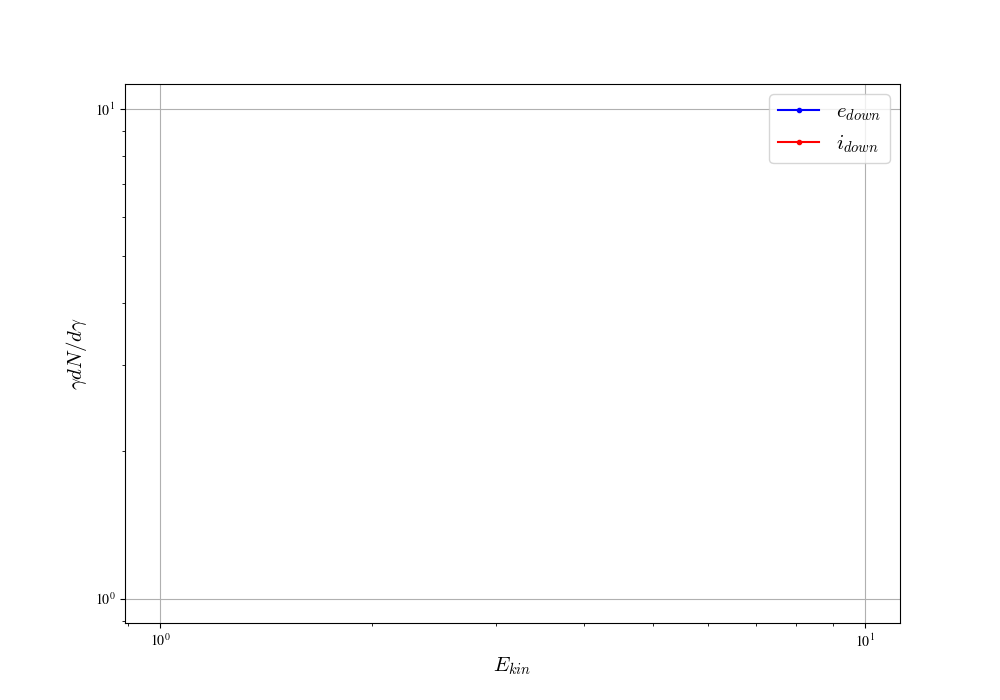

In [ ]:
# %matplotlib inline

x = -1
file = h5py.File(files[x], 'r')['Step0']
mi=25

def AngDist(x1, x2, spec, file):
    if spec == 1:
        m = 1.
    else:
        m = mi
    spec = str(spec)
    x = np.array(file['pX1_' + spec])
    u1 = np.array(file['pU1_'+ spec])
    u2 = np.array(file['pU2_'+ spec])
    u3 = np.array(file['pU3_'+ spec])

    targidx = np.argwhere((x1< x) & (x < x2)).flatten()
    u1 = u1[targidx]
    u2 = u2[targidx]
    u3 = u3[targidx]

    v1 = u1 / np.sqrt(1 + u1**2 + u2**2 + u3**2)
    v2 = u2 / np.sqrt(1 + u1**2 + u2**2 + u3**2)
    v3 = u3 / np.sqrt(1 + u1**2 + u2**2 + u3**2)

    V1 = v1.mean()
    V2 = v2.mean()
    V3 = v3.mean()
    V = np.array([V1, V2, V3])
    V2_mag2 = np.dot(V, V)
    gamma_V = 1 / np.sqrt(1 - V2_mag2)

    v_particle = np.stack([v1, v2, v3], axis=1)

    dot = np.sum(v_particle * V, axis=1)
    factor = 1 / (1 - dot)
    v_rel = (v_particle - V) * factor[:, None]

    v_mod = np.linalg.norm(v_rel, axis=1) #* np.sqrt(m)

    gm = 1 / np.sqrt(1 - v_mod**2)

    v_mod = (gm-1) * m

    if v_mod.shape[0] == 0:
        return (np.array([]),np.array([]))
    bins = np.logspace(np.log10(v_mod.min() + 1e-8), np.log10(v_mod.max()), 50)
    img = np.histogram(v_mod, bins=bins, density=True)
    # plt.close()
    
    return (img[1][:-1], img[0][:])


def func(x, ynorm, xnorm,sig):
    return ynorm * np.exp(-((x - xnorm) / sig)**2)



from scipy.optimize import curve_fit


plt.figure(figsize=(10,7))

def integrate(x,y):
    return ((y[1:]+ y[:-1])/2*(x[1:] - x[:-1])).sum()


def plotvdis(xlow, xhigh, spec, file, label, color):
    xu,yu = AngDist(xlow, xhigh,spec,file)
    plt.plot(xu,yu*xu, label=label, marker = '.', color = color)
    return integrate(xu,xu*yu) /integrate(xu,yu) #xu[np.where(yu*xu == (yu*xu).max())]

ted = plotvdis(100,300,1,file,r'$e_{down}$', 'blue')
tid = plotvdis(100,300,2,file, r'$i_{down}$', 'red')
# tid = plotvdis(1500,1700,2,file, r'$i_{down}$', 'red')

plt.legend(fontsize = 15)
plt.xscale('log')
plt.yscale('log')

plt.ylabel(r'$\gamma dN/d\gamma$',fontsize = 15)
plt.xlabel(r'$E_{kin}$',fontsize = 15)

plt.grid()
# plt.savefig('mbdist_strongscatt.png', dpi=300)
